<h3>Ralph Richmond D. Amariilo</h3>
<h3>Nerjie Angelo Mecantina 
<hr>
<h1>Finals Project: <strong>Family Income and Expenditure</strong></h1>
<hr>
<strong>Course</strong>: Data Analytics with Python

<strong>Instructor</strong>: Leonard Andrew Mesiera  
<strong>Due Date</strong>: November 27, 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [2]:
FIE = pd.read_csv('datasets\\Family Income and Expenditure.csv')
FIE.head()

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,1,0,0,0,3,1,0,0,2
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,0,0,0
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,0,0,0,0,1,0,0,0,0
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,1,0,0,0,0,3,0,0,0,1


In [3]:
FIE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41544 entries, 0 to 41543
Data columns (total 60 columns):
 #   Column                                         Non-Null Count  Dtype 
---  ------                                         --------------  ----- 
 0   Total Household Income                         41544 non-null  int64 
 1   Region                                         41544 non-null  object
 2   Total Food Expenditure                         41544 non-null  int64 
 3   Main Source of Income                          41544 non-null  object
 4   Agricultural Household indicator               41544 non-null  int64 
 5   Bread and Cereals Expenditure                  41544 non-null  int64 
 6   Total Rice Expenditure                         41544 non-null  int64 
 7   Meat Expenditure                               41544 non-null  int64 
 8   Total Fish and  marine products Expenditure    41544 non-null  int64 
 9   Fruit Expenditure                              41544 non-null

In [4]:
FIE.isnull().sum()

Total Household Income                              0
Region                                              0
Total Food Expenditure                              0
Main Source of Income                               0
Agricultural Household indicator                    0
Bread and Cereals Expenditure                       0
Total Rice Expenditure                              0
Meat Expenditure                                    0
Total Fish and  marine products Expenditure         0
Fruit Expenditure                                   0
Vegetables Expenditure                              0
Restaurant and hotels Expenditure                   0
Alcoholic Beverages Expenditure                     0
Tobacco Expenditure                                 0
Clothing, Footwear and Other Wear Expenditure       0
Housing and water Expenditure                       0
Imputed House Rental Value                          0
Medical Care Expenditure                            0
Transportation Expenditure  

In [5]:
print("Summary Statistics:")
FIE[['Total Household Income', 'Total Food Expenditure']].describe()

Summary Statistics:


,Total Household Income,Total Food Expenditure
count,4.154400e+04,41544.000000
mean,2.475556e+05,85099.158194
std,2.868805e+05,51637.947682
min,1.128500e+04,2947.000000
25%,1.048950e+05,51017.250000
50%,1.640795e+05,72985.500000
75%,2.911385e+05,105635.500000
max,1.181599e+07,827565.000000


In [6]:
FIE[['Total Household Income', 'Total Food Expenditure']].corr()

,Total Household Income,Total Food Expenditure
Total Household Income,1.00000,0.66366
Total Food Expenditure,0.66366,1.00000


In [7]:
FIE.groupby('Agricultural Household indicator')['Total Food Expenditure'].mean()

Agricultural Household indicator
0     87979.702555
1     60992.419273
2    115966.577149
Name: Total Food Expenditure, dtype: float64

In [8]:
X = FIE[['Total Household Income']]
y = FIE['Total Food Expenditure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Prediction Example (income = 200,000):")
prediction = model.predict(pd.DataFrame({'Total Household Income': [200000]}))
print(prediction)

Prediction Example (income = 200,000):
[79380.00432999]


<hr>
<strong>DESCRIPTIVE ANALYTICS</strong>
<hr>

<h1>Food Expenditure Distribution</h1>

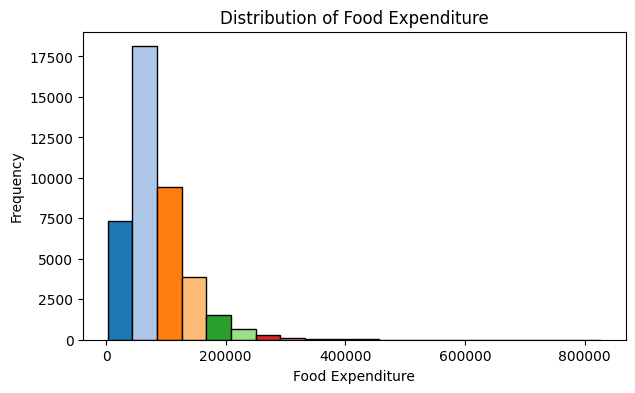

In [30]:
data = FIE["Total Food Expenditure"].dropna()

plt.figure(figsize=(7,4))
counts, bins, patches = plt.hist(data, bins=20, edgecolor='black')

for patch, color in zip(patches, plt.cm.tab20(np.linspace(0, 1, len(patches)))):
    patch.set_facecolor(color)

plt.title("Distribution of Food Expenditure")
plt.xlabel("Food Expenditure")
plt.ylabel("Frequency")
plt.show()

Insight:

Food spending is also right-skewed most households spend moderately on food, with a small number spending much higher amounts.
This confirms that <strong>food cost scales with income</strong>.
<ul>
    <strong>Why it’s great:</strong>
    <li> Shows food spending patterns</li>
    <li> Works well with predictive modeling later</li>
</ul>
<hr>

<h1>PC Ownership /</h1>

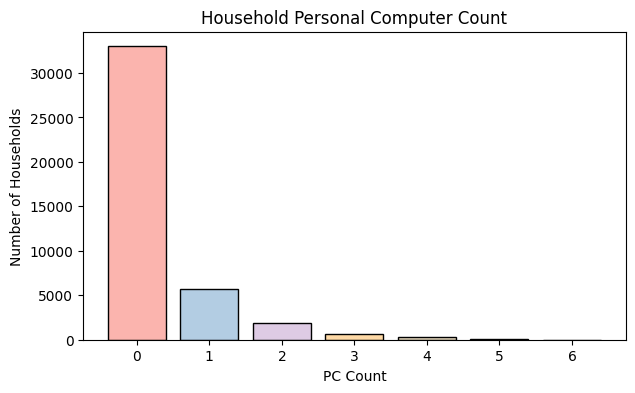

In [11]:
pc_counts = FIE["Number of Personal Computer"].value_counts().sort_index()

plt.figure(figsize=(7,4))

colors = plt.cm.Pastel1(np.linspace(0, 1, len(pc_counts)))

plt.bar(pc_counts.index, pc_counts.values, color=colors, edgecolor="black")
plt.title("Household Personal Computer Count")
plt.xlabel("PC Count")
plt.ylabel("Number of Households")
plt.show()

Insight:

The majority of households own <strong>0 or 1 computer</strong>, suggesting limited digital access.
Higher PC ownership indicates <strong>richer households</strong>.
<ul>
    <strong>Why it’s great:</strong>
    <li> Shows living standards and economic capacity</li>
    <li> Easy to explain</li>
</ul>
<hr>

<hr>
<strong>DIAGNOSTIC ANALYTICS</strong>
<hr>

<h1>Correlation Heatmap /</h1>

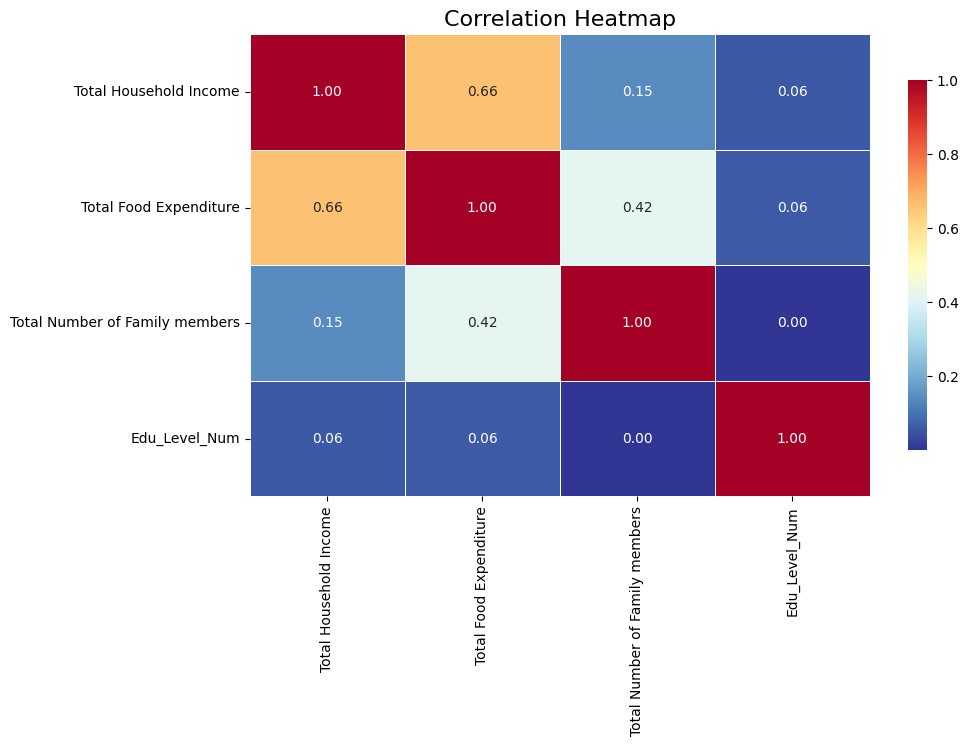

In [20]:
FIE['Edu_Level_Num'] = FIE['Household Head Highest Grade Completed'].astype('category').cat.codes

corr_matrix = FIE[['Total Household Income',
                   'Total Food Expenditure',
                   'Total Number of Family members',
                   'Edu_Level_Num']].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='RdYlBu_r', 
            linewidths=0.5, 
            linecolor='white',
            cbar_kws={'shrink':0.8})

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

<strong>Insight:</strong>

Income, education, and food expenditure show noticeable positive relationships, helping identify which socioeconomic factors influence spending behavior; <strong>higher education levels correspond to higher income, which in turn affects expenditure.</strong>
<ul>
    <strong>Why it’s great:</strong>
    <li> Shows relationships</li>
    <li> Perfect for Diagnostic + Predictive discussion</li>
</ul>

<hr>
<strong>PREDICTIVE ANALYTICS</strong>
<hr>

<h1>Scatter Plot (in regression section) /</h1>

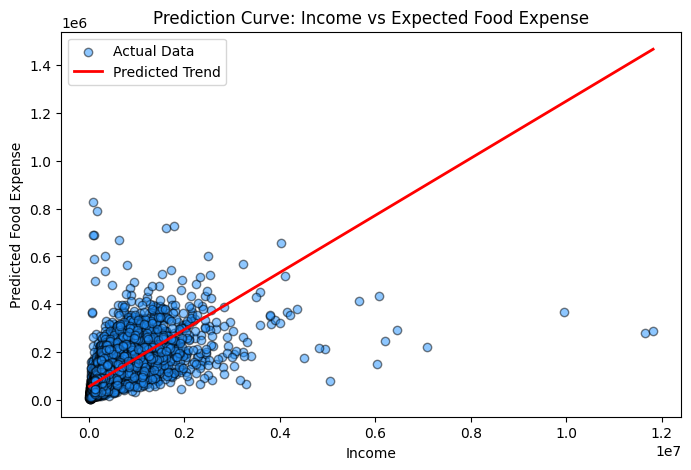

In [28]:
X = FIE[['Total Household Income']] 
y = FIE['Total Food Expenditure']    

model = LinearRegression()
model.fit(X, y)

income_range = pd.DataFrame(
    np.linspace(X['Total Household Income'].min(), 
                X['Total Household Income'].max(), 
                100),
    columns=['Total Household Income']
)

prediction = model.predict(income_range)
plt.figure(figsize=(8,5))
plt.scatter(FIE['Total Household Income'], 
            FIE['Total Food Expenditure'], 
            color='dodgerblue', alpha=0.5, label='Actual Data', edgecolor='black')
plt.plot(income_range, prediction, color='red', linewidth=2, label='Predicted Trend')

plt.title("Prediction Curve: Income vs Expected Food Expense")
plt.xlabel("Income")
plt.ylabel("Predicted Food Expense")
plt.legend()
plt.show()

<strong>Insight</strong>

This illustrates how predicted food expenses change across income levels, <strong>showing that food spending rises gradually as income increases.</strong>
<ul>
    <strong>Why it’s great:</strong>
    <li> This is the Predictive Analytics highlight</li>
    <li> Shows the relationship clearly</li>
</ul>
<hr>

<h1>Predictive Trend Line (Income → Food Expenditure) /</h1>

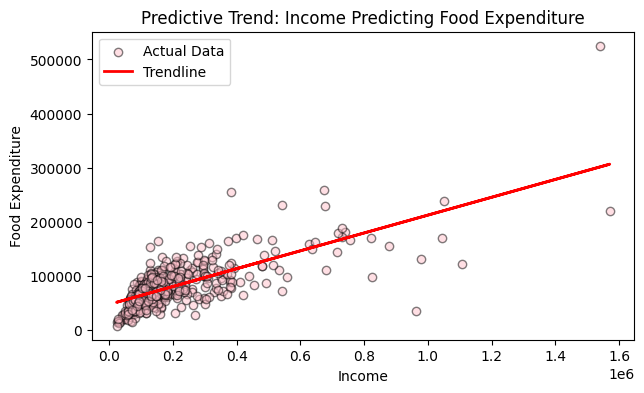

In [22]:
income = FIE["Total Household Income"].dropna().iloc[:500]
food = FIE["Total Food Expenditure"].dropna().iloc[:500]

m, b = np.polyfit(income, food, 1)

plt.figure(figsize=(7,4))

plt.scatter(income, food, color='pink', alpha=0.5, edgecolor='black', label='Actual Data')

plt.plot(income, m*income + b, color='red', linewidth=2, label='Trendline')

plt.title("Predictive Trend: Income Predicting Food Expenditure")
plt.xlabel("Income")
plt.ylabel("Food Expenditure")
plt.legend()
plt.show()

<strong>Insight:</strong>

A regression line shows a strong linear trend:
<strong>Higher income → Higher food spending</strong>

This model can be used to <strong>predict future or unknown food expenditures</strong> based on income.

<ul>
    <strong>Why it’s great:</strong>
    <li> Shows prediction capability</li>
    <li> Perfect for discussion of Predictive Analytics</li>
</ul>